Época 1: Pesos = [0.1 0.1], Sesgo = 0.0
Época 2: Pesos = [0.2 0.1], Sesgo = -0.1
Época 3: Pesos = [0.2 0.1], Sesgo = -0.20000000000000004
Época 4: Pesos = [0.2 0.1], Sesgo = -0.20000000000000004
Época 5: Pesos = [0.2 0.1], Sesgo = -0.20000000000000004
Época 6: Pesos = [0.2 0.1], Sesgo = -0.20000000000000004
Época 7: Pesos = [0.2 0.1], Sesgo = -0.20000000000000004
Época 8: Pesos = [0.2 0.1], Sesgo = -0.20000000000000004
Época 9: Pesos = [0.2 0.1], Sesgo = -0.20000000000000004
Época 10: Pesos = [0.2 0.1], Sesgo = -0.20000000000000004

Predicciones finales:
Entrada: [0 0] -> Predicción: 0
Entrada: [0 1] -> Predicción: 0
Entrada: [1 0] -> Predicción: 0
Entrada: [1 1] -> Predicción: 1


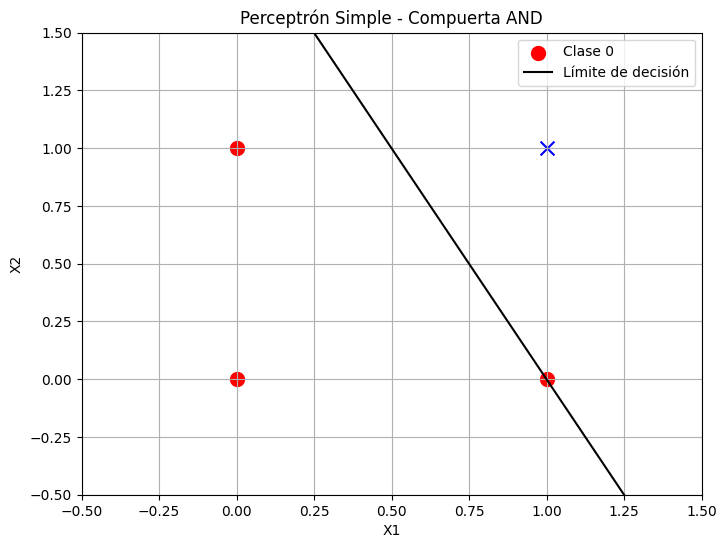

In [1]:
import numpy as np
import matplotlib.pyplot as plt

class PerceptronSimple:
    def __init__(self, tasa_aprendizaje=0.1, n_epocas=10):
        self.tasa_aprendizaje = tasa_aprendizaje
        self.n_epocas = n_epocas
        self.pesos = None
        self.sesgo = None

    def activacion(self, x):
        return 1 if x >= 0 else 0

    def entrenar(self, X, y):
        # Inicializar pesos y sesgo
        n_caracteristicas = X.shape[1]
        self.pesos = np.zeros(n_caracteristicas)
        self.sesgo = 0

        # Entrenamiento
        for epoca in range(self.n_epocas):
            for i in range(len(X)):
                # Calcular salida
                suma = np.dot(X[i], self.pesos) + self.sesgo
                y_pred = self.activacion(suma)

                # Actualizar pesos y sesgo
                error = y[i] - y_pred
                self.pesos += self.tasa_aprendizaje * error * X[i]
                self.sesgo += self.tasa_aprendizaje * error

            print(f"Época {epoca + 1}: Pesos = {self.pesos}, Sesgo = {self.sesgo}")

    def predecir(self, X):
        y_pred = []
        for i in range(len(X)):
            suma = np.dot(X[i], self.pesos) + self.sesgo
            y_pred.append(self.activacion(suma))
        return np.array(y_pred)

# Datos de entrenamiento: Compuerta AND
# Entrada: (x1, x2), Salida: y
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 0, 0, 1])

# Crear y entrenar el perceptrón
perceptron = PerceptronSimple(tasa_aprendizaje=0.1, n_epocas=10)
perceptron.entrenar(X, y)

# Probar el modelo
predicciones = perceptron.predecir(X)
print("\nPredicciones finales:")
for i in range(len(X)):
    print(f"Entrada: {X[i]} -> Predicción: {predicciones[i]}")

# Visualizar resultados
plt.figure(figsize=(8, 6))

# Graficar puntos de datos
for i in range(len(X)):
    if y[i] == 0:
        plt.scatter(X[i][0], X[i][1], color='red', marker='o', s=100, label='Clase 0' if i == 0 else "")
    else:
        plt.scatter(X[i][0], X[i][1], color='blue', marker='x', s=100, label='Clase 1' if i == 2 else "")

# Graficar línea de decisión
x1_min, x1_max = -0.5, 1.5
x2_min, x2_max = -0.5, 1.5

xx = np.linspace(x1_min, x1_max)
yy = (-perceptron.pesos[0] * xx - perceptron.sesgo) / perceptron.pesos[1]
plt.plot(xx, yy, 'k-', label='Límite de decisión')

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Perceptrón Simple - Compuerta AND')
plt.legend()
plt.grid(True)
plt.axis([x1_min, x1_max, x2_min, x2_max])
plt.show()

Dataset Iris cargado:
- Número de muestras: 150
- Número de características: 4
- Número de clases: 3
- Clases: [0 1 2]
- Nombres de clases: ['setosa' 'versicolor' 'virginica']

Arquitectura de la red: [4, 10, 3]
Iniciando entrenamiento...
Época 0: Pérdida = 1.3053, Precisión = 0.1583
Época 100: Pérdida = 0.5608, Precisión = 0.8917
Época 200: Pérdida = 0.3925, Precisión = 0.9167
Época 300: Pérdida = 0.3218, Precisión = 0.9167
Época 400: Pérdida = 0.2768, Precisión = 0.9250
Época 500: Pérdida = 0.2422, Precisión = 0.9333
Época 600: Pérdida = 0.2133, Precisión = 0.9417
Época 700: Pérdida = 0.1884, Precisión = 0.9500
Época 800: Pérdida = 0.1675, Precisión = 0.9583
Época 900: Pérdida = 0.1501, Precisión = 0.9583

--- RESULTADOS FINALES ---
Precisión en entrenamiento: 0.9667
Precisión en prueba: 0.9333

Reporte de Clasificación:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.90      0.90      0.90        10
  

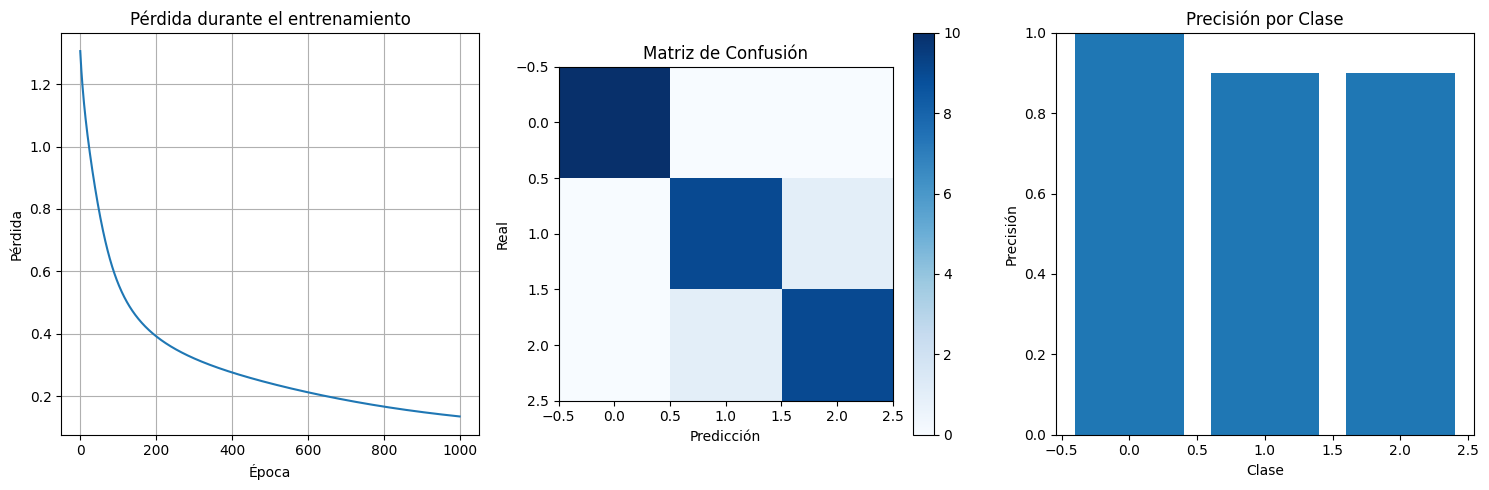


--- PREDICCIÓN DE EJEMPLO ---
Predicción: Setosa
Real: Setosa
¿Correcto?: True


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

class PerceptronMulticapa:
    def __init__(self, capas, tasa_aprendizaje=0.01, epocas=1000):
        self.capas = capas  # [entrada, oculta1, ..., salida]
        self.tasa_aprendizaje = tasa_aprendizaje
        self.epocas = epocas
        self.pesos = []
        self.sesgos = []
        self.historial_perdida = []
        
        # Inicializar pesos y sesgos
        for i in range(len(capas) - 1):
            # Inicialización Xavier/Glorot para mejor convergencia
            limite = np.sqrt(6 / (capas[i] + capas[i+1]))
            peso = np.random.uniform(-limite, limite, (capas[i], capas[i+1]))
            sesgo = np.zeros((1, capas[i+1]))
            self.pesos.append(peso)
            self.sesgos.append(sesgo)
    
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-np.clip(x, -250, 250)))  # clip para evitar overflow
    
    def derivada_sigmoid(self, x):
        return x * (1 - x)
    
    def softmax(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)
    
    def forward(self, X):
        activaciones = [X]
        for i in range(len(self.pesos)):
            z = np.dot(activaciones[-1], self.pesos[i]) + self.sesgos[i]
            if i == len(self.pesos) - 1:
                # Capa de salida: softmax para clasificación multiclase
                a = self.softmax(z)
            else:
                # Capas ocultas: sigmoid
                a = self.sigmoid(z)
            activaciones.append(a)
        return activaciones
    
    def backward(self, activaciones, y):
        m = y.shape[0]
        deltas = [None] * len(self.pesos)
        
        # Error en la capa de salida
        error = activaciones[-1] - y
        deltas[-1] = error
        
        # Backpropagation
        for i in range(len(self.pesos) - 2, -1, -1):
            error = np.dot(deltas[i+1], self.pesos[i+1].T) * self.derivada_sigmoid(activaciones[i+1])
            deltas[i] = error
        
        # Actualizar pesos y sesgos
        for i in range(len(self.pesos)):
            grad_pesos = np.dot(activaciones[i].T, deltas[i]) / m
            grad_sesgos = np.sum(deltas[i], axis=0, keepdims=True) / m
            
            self.pesos[i] -= self.tasa_aprendizaje * grad_pesos
            self.sesgos[i] -= self.tasa_aprendizaje * grad_sesgos
    
    def calcular_perdida(self, y_pred, y_true):
        # Entropía cruzada para múltiples clases
        m = y_true.shape[0]
        perdida = -np.sum(y_true * np.log(y_pred + 1e-8)) / m
        return perdida
    
    def entrenar(self, X, y):
        # Convertir y a one-hot encoding si es necesario
        if len(y.shape) == 1:
            y_one_hot = np.eye(self.capas[-1])[y]
        else:
            y_one_hot = y
        
        for epoca in range(self.epocas):
            # Forward propagation
            activaciones = self.forward(X)
            y_pred = activaciones[-1]
            
            # Calcular pérdida
            perdida = self.calcular_perdida(y_pred, y_one_hot)
            self.historial_perdida.append(perdida)
            
            # Backward propagation
            self.backward(activaciones, y_one_hot)
            
            if epoca % 100 == 0:
                accuracy = self.accuracy(X, y)
                print(f"Época {epoca}: Pérdida = {perdida:.4f}, Precisión = {accuracy:.4f}")
    
    def predecir(self, X):
        activaciones = self.forward(X)
        return np.argmax(activaciones[-1], axis=1)
    
    def accuracy(self, X, y):
        predicciones = self.predecir(X)
        return np.mean(predicciones == y)

# Cargar y preparar los datos
def cargar_datos():
    iris = load_iris()
    X = iris.data
    y = iris.target
    
    print("Dataset Iris cargado:")
    print(f"- Número de muestras: {X.shape[0]}")
    print(f"- Número de características: {X.shape[1]}")
    print(f"- Número de clases: {len(np.unique(y))}")
    print(f"- Clases: {np.unique(y)}")
    print(f"- Nombres de clases: {iris.target_names}")
    
    return X, y

# Preprocesamiento de datos
def preprocesar_datos(X, y):
    # Normalizar las características
    scaler = StandardScaler()
    X_normalizado = scaler.fit_transform(X)
    
    # Dividir en entrenamiento y prueba
    X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
        X_normalizado, y, test_size=0.2, random_state=42, stratify=y
    )
    
    return X_entrenamiento, X_prueba, y_entrenamiento, y_prueba

# Visualizaciones
def visualizar_resultados(modelo, X_prueba, y_prueba, historial_perdida):
    # Gráfico de la pérdida durante el entrenamiento
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.plot(historial_perdida)
    plt.title('Pérdida durante el entrenamiento')
    plt.xlabel('Época')
    plt.ylabel('Pérdida')
    plt.grid(True)
    
    # Matriz de confusión
    plt.subplot(1, 3, 2)
    y_pred = modelo.predecir(X_prueba)
    cm = confusion_matrix(y_prueba, y_pred)
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Matriz de Confusión')
    plt.colorbar()
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    
    # Precisión por clase
    plt.subplot(1, 3, 3)
    accuracy_por_clase = []
    clases = np.unique(y_prueba)
    for clase in clases:
        mask = y_prueba == clase
        accuracy_clase = np.mean(y_pred[mask] == y_prueba[mask])
        accuracy_por_clase.append(accuracy_clase)
    
    plt.bar(clases, accuracy_por_clase)
    plt.title('Precisión por Clase')
    plt.xlabel('Clase')
    plt.ylabel('Precisión')
    plt.ylim(0, 1)
    
    plt.tight_layout()
    plt.show()

# Programa principal
def main():
    # Cargar y preparar datos
    X, y = cargar_datos()
    X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = preprocesar_datos(X, y)
    
    # Configurar la red neuronal
    # [4 características de entrada, 10 neuronas ocultas, 3 clases de salida]
    capas = [4, 10, 3]
    mlp = PerceptronMulticapa(capas=capas, tasa_aprendizaje=0.1, epocas=1000)
    
    print(f"\nArquitectura de la red: {capas}")
    print("Iniciando entrenamiento...")
    
    # Entrenar el modelo
    mlp.entrenar(X_entrenamiento, y_entrenamiento)
    
    # Evaluar el modelo
    accuracy_entrenamiento = mlp.accuracy(X_entrenamiento, y_entrenamiento)
    accuracy_prueba = mlp.accuracy(X_prueba, y_prueba)
    
    print(f"\n--- RESULTADOS FINALES ---")
    print(f"Precisión en entrenamiento: {accuracy_entrenamiento:.4f}")
    print(f"Precisión en prueba: {accuracy_prueba:.4f}")
    
    # Reporte de clasificación detallado
    y_pred = mlp.predecir(X_prueba)
    print(f"\nReporte de Clasificación:")
    print(classification_report(y_prueba, y_pred, target_names=['Setosa', 'Versicolor', 'Virginica']))
    
    # Visualizar resultados
    visualizar_resultados(mlp, X_prueba, y_prueba, mlp.historial_perdida)
    
    # Ejemplo de predicción
    print("\n--- PREDICCIÓN DE EJEMPLO ---")
    ejemplo_idx = 0
    ejemplo = X_prueba[ejemplo_idx:ejemplo_idx+1]
    prediccion_real = mlp.predecir(ejemplo)[0]
    clase_real = y_prueba[ejemplo_idx]
    
    nombres_clases = ['Setosa', 'Versicolor', 'Virginica']
    print(f"Predicción: {nombres_clases[prediccion_real]}")
    print(f"Real: {nombres_clases[clase_real]}")
    print(f"¿Correcto?: {prediccion_real == clase_real}")

if __name__ == "__main__":
    main()

In [7]:
-0.5 * ( 0.01*np.log(0.01) + 0.99*np.log(0.99) )

-0.5 * ( 0.01*np.log(0.99) + 0.99*np.log(0.01) )

np.float64(2.2796094937433726)